**2026 ASA South Florida Student Data Challenge**

Name: Kiran Pittan

School: University of Central Florida (Undergraduate)

**Understanding the Dataset**

In [1]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/luminwin/ASASF/main/train.csv"
df = pd.read_csv(train_url)

print(df.head())

   Unnamed: 0  LBDHDD_outcome  DR1TKCAL  DR1TPROT  DR1TCARB  DR1TSUGR  \
0           1       51.169706      1459     39.95    152.46     50.34   
1           2       64.129747      2116     82.54    213.12     75.49   
2           3       43.333345      2417     61.59    242.22     69.35   
3           4       58.853188      2018     39.99    206.45     50.56   
4           5       40.239688      2331     89.59    307.36    161.17   

   DR1TFIBE  DR1TTFAT  DR1TSFAT  DR1TMFAT  ...  RIAGENDR  INDFMPIR  DMDMARTZ  \
0      13.6     78.41    18.062    29.440  ...         2      2.17         1   
1      12.7    103.08    48.495    23.529  ...         2      1.03         1   
2      14.7    104.62    30.182    31.087  ...         1      3.31         1   
3      17.2     42.75    12.418    13.011  ...         2      3.82         1   
4      20.1     85.28    22.278    30.190  ...         1      2.58         2   

   RIDAGEYR  RIDRETH1  RIDRETH3  BMXBMI  BMXWAIST  ALQ111  ALQ121  
0        72 

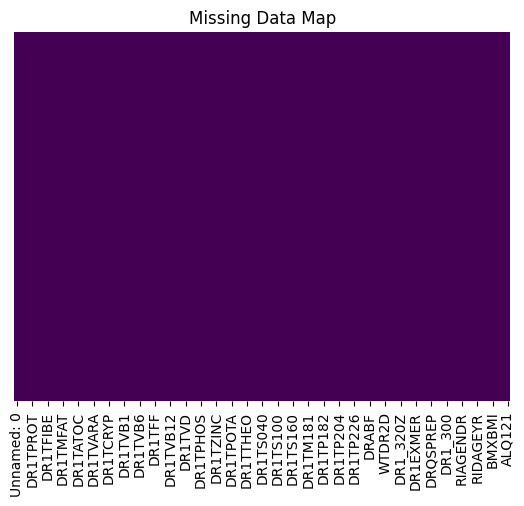

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Map")
plt.show()

This heatmap shows that there are no missing data present. viridis maps "False" (not missing) as purple and "True" (missing) as yellow. This is fantastic news as this dataset is a good baseline for a stable Simple Linear Regression model.

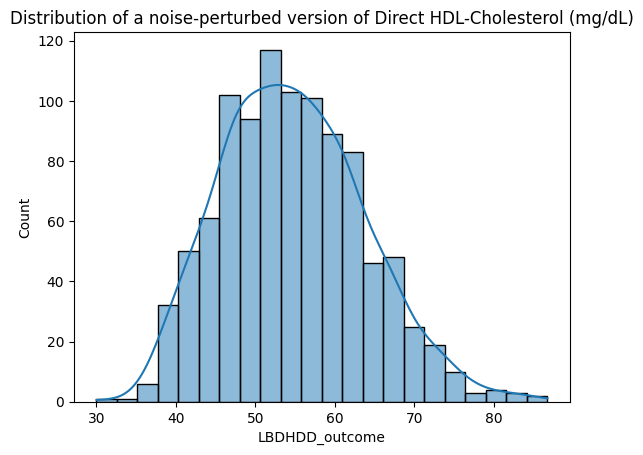

In [3]:
sns.histplot(df['LBDHDD_outcome'], kde=True)
plt.title('Distribution of a noise-perturbed version of Direct HDL-Cholesterol (mg/dL)')
plt.show()

Mostly Bell Shaped (good for simple linear regression)

Slight right skew

Peaks between 50-55 mg/dL

We can see that there are few individuals with very high HDL cholesterol so it might be harder for a basic model to predict accurately. Since performance is judged on RMSE, outliers in that right-side tail can hurt the score significantly. The predictions for the test set should also lie between 30 and 90 as seen on the histogram.

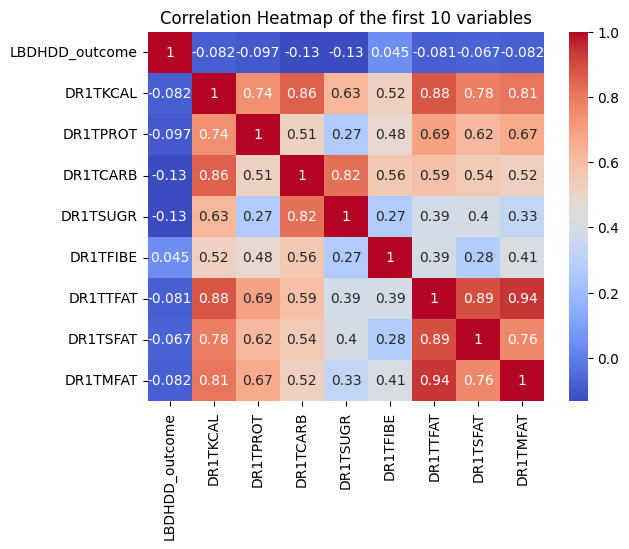

In [4]:
sns.heatmap(df.iloc[1:,1:10].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of the first 10 variables")
plt.show()

As you can see from the Correlation Heatmap, we see that DR1TTFAT, DR1TSFAT and DR1TMFAT are multicollinear. Hence, when doing simple linear regression, so as to not make the model unstable, I am only going to remove DR1TSFAT and DR1TMFAT. XGBoost regression models are able to handle multicollinearity however, removing these variables makes the model faster and can reduce overfitting.

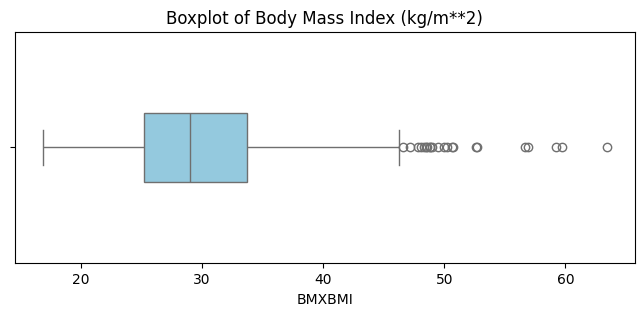

In [5]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['BMXBMI'], width=0.3, color='skyblue')
plt.title('Boxplot of Body Mass Index (kg/m**2)')
plt.show()

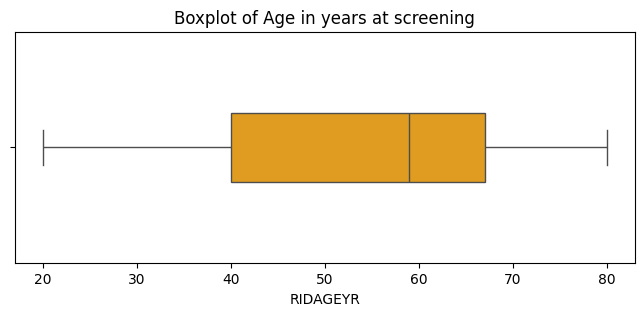

In [6]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['RIDAGEYR'], width=0.3, color='orange')
plt.title('Boxplot of Age in years at screening')
plt.show()

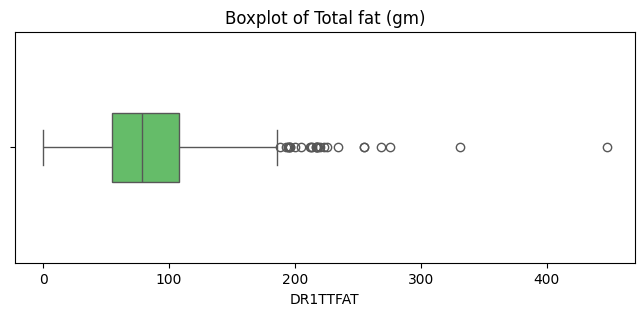

In [7]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['DR1TTFAT'], width=0.3, color="#57CA5C")
plt.title('Boxplot of Total fat (gm)')
plt.show()

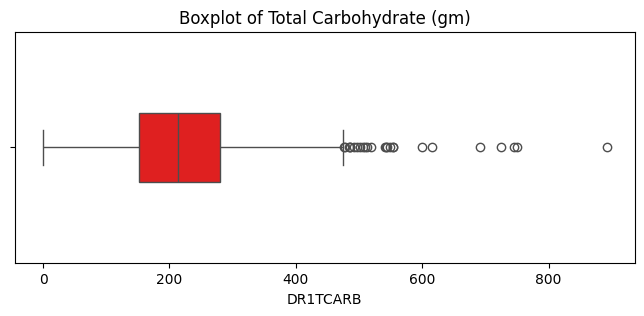

In [8]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['DR1TCARB'], width=0.3, color='red')
plt.title('Boxplot of Total Carbohydrate (gm)')
plt.show()

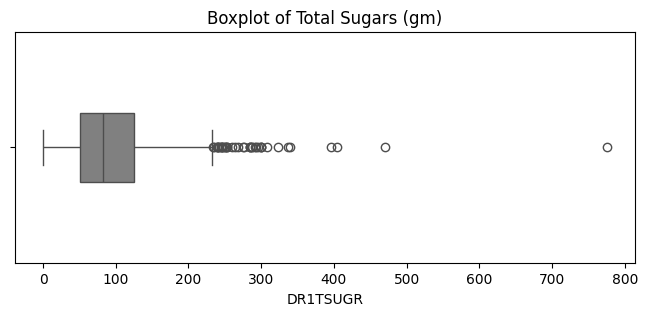

In [9]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['DR1TSUGR'], width=0.3, color='grey')
plt.title('Boxplot of Total Sugars (gm)')
plt.show()

From these 5 boxplots, we can see that there are outliers in the variables, BMI, Total Fat, Total Carbohyrade, and Total Sugar. These outliers can affect RMSE so I plan on using Winsorization to clip the extreme values at a specific percentile to achieve a better RMSE for my simple linear regression model. I would also like to run a simple regression model without winsorization to see the difference in RMSE. Unlike simple linear regression, tree-based models like XGBoost are highly robust to outliers so I will be running a XGBoost model without winsorization. Winsorization might even hurt those models.

**Cleaning and Preprocessing**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

test_url = "https://raw.githubusercontent.com/luminwin/ASASF/main/test.csv"
df_test = pd.read_csv(test_url)

train_url = "https://raw.githubusercontent.com/luminwin/ASASF/main/train.csv"
df_train = pd.read_csv(train_url)

def prepare_data(df, is_train=True):
    X = df.copy()
    y = None

    if is_train and 'LBDHDD_outcome' in X.columns:
        y = X['LBDHDD_outcome']
    
    cols_to_drop = ['LBDHDD_outcome', 'DR1TSFAT', 'DR1TMFAT', 'Unnamed: 0']
    X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

    X = X.fillna(X.median())
    return X, y

def winsorization(X_input):
    X = X_input.copy()
    outlier_cols = ['BMXBMI', 'DR1TTFAT', 'DR1TCARB', 'DR1TSUGR']
    for col in outlier_cols:
        if col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            X[col] = np.clip(X[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return X

X_all, y_all = prepare_data(df_train, is_train=True)

X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, random_state=21)

X_train_clipped = winsorization(X_train)
X_val_clipped = winsorization(X_val)

Now that I have cleaned and preprocessed the dataset, we can move on to Simple Linear Regression.

**Simple Linear Regression**

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


lr_unclipped = LinearRegression()
lr_unclipped.fit(X_train, y_train)

preds_unclipped = lr_unclipped.predict(X_val)
rmse_unclipped = np.sqrt(mean_squared_error(y_val, preds_unclipped))

lr_clipped = LinearRegression()
lr_clipped.fit(X_train_clipped, y_train)

preds_clipped = lr_clipped.predict(X_val_clipped)
rmse_clipped = np.sqrt(mean_squared_error(y_val, preds_clipped))

print(f"Unclipped Linear Regression RMSE: {rmse_unclipped:.3f}")
print(f"Winsorized Linear Regression RMSE: {rmse_clipped:.3f}")

Unclipped Linear Regression RMSE: 5.856
Winsorized Linear Regression RMSE: 5.830


The Unclipped Linear Regression RMSE is 5.856 while the Winsorized Linear Regression RMSE is 5.830. Honestly, I was expecting an improvement far more than 0.026. Although, I had only winsorized 4 variables out of 97 hence the smaller than expected improvement. An improvement of 0.026 might seem pathetic but it could make a difference in a competition. I could winsorize all the variables and eke out a better RMSE but I have another weapon in my arsenal to help achieve a way better improvement. XGBoost regression could help me get a far better RMSE and furthermore, I do not even need to winsorize my dataset.

**XGBoost Regression**

In [12]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=21
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f"Winsorized Linear Regression RMSE: {rmse_clipped:.3f}")
print(f"XGBoost Regression RMSE: {rmse_xgb:.3f}")

Winsorized Linear Regression RMSE: 5.830
XGBoost Regression RMSE: 4.693


The XGBoost Regression RMSE is 4.693. This is a big improvement of 1.137 compared to my last model, which surpassed my expectations. However, I know I can improve this model even more if I were to fine tune the settings on my XGBoost regressor. Rather than changing the settings manually one by one like an amateur, I am instead going to use GridSearchCV to test which setting provides the best outcome.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,9],
    'learning_rate': [0.01,0.05,0.1,0.2],
    'n_estimators': [100,200,500,1000],
    'subsample': [0.8],
    'random_state': [21]
}

grid_search = GridSearchCV(xgb.XGBRegressor(), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'random_state': 21, 'subsample': 0.8}


GridSearchCV is telling me that the best settings to choose are 'learning_rate': 0.05, 'max_depth': 3 and 'n_estimators': 200.

Let's see the difference with the new settings.

In [14]:
import xgboost as xgb

xgb_model2 = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=21
)

xgb_model2.fit(X_train, y_train)

xgb_preds = xgb_model2.predict(X_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, xgb_preds))

print(f"XGBoost Regression (Improved) RMSE: {rmse_xgb:.3f}")

XGBoost Regression (Improved) RMSE: 4.564


Using the best setting as suggested by GridSearchCV, I am able to improve the RMSE even further, reducing it by 0.129. This improved XGBoost Regression model has a RMSE of 4.564. I started with a RMSE of 5.856 so thats an improvement of 22%, which is fantastic.

In [15]:
best_model = grid_search.best_estimator_

X_test_final, _ = prepare_data(df_test, is_train=False)

final_predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({'pred': final_predictions})
submission.to_csv('pred.csv', index=False)

print(f"Submission file 'pred.csv' created with {len(submission)} predictions.")

Submission file 'pred.csv' created with 200 predictions.


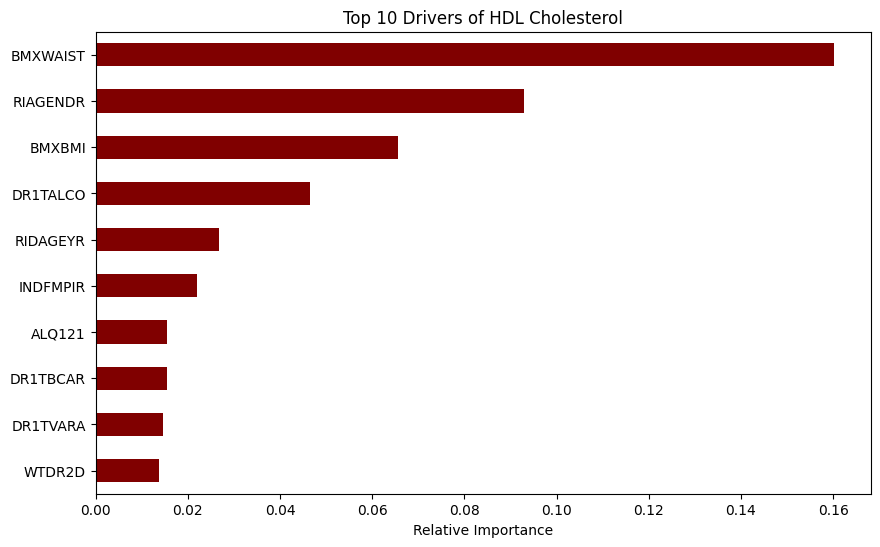

In [16]:
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X_test_final.columns)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='maroon')
plt.title('Top 10 Drivers of HDL Cholesterol')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.show()

According to the model, Waist Circumference (cm), Age in years at screening and Body Mass Index (kg/m^2) were the 3 most important predictors. This is realistic hence I am able to conclude that XGBoost model was working fine. 